In [13]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_openai import ChatOpenAI
import os
import operator

In [14]:
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
openrouter_base_url = "https://openrouter.ai/api/v1"

generator_llm = ChatOpenAI(
    model="Qwen/Qwen3-235B-A22B",
    api_key=openrouter_api_key,
    base_url=openrouter_base_url,
    temperature=0.7,
    )

evaluation_llm = ChatOpenAI(
    model="Qwen/Qwen3-235B-A22B",
    api_key=openrouter_api_key,
    base_url=openrouter_base_url,
    temperature=0,
    )

# deepeval_llm = ChatOpenAI(
#     model="anthropic/claude-3-5-sonnet-20241022",
#     api_key=openrouter_api_key,
#     base_url=openrouter_base_url,
#     temperature=0,
#     )

optimization_llm = ChatOpenAI(
    model="anthropic/claude-3-5-sonnet-20241022",
    api_key=openrouter_api_key,
    base_url=openrouter_base_url,
    temperature=0,
    )

In [15]:
class TweetState(TypedDict):

    topic : str
    tweet : str
    evaluation : Literal["approved","need_improvement"]
    feedback : str
    iteration : int
    max_iteration : int

    tweet_history : Annotated[list[str],operator.add]
    feedback_history : Annotated[list[str],operator.add]


In [16]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [17]:
import json, re

# Use evaluation_llm directly (no structured output - we'll parse JSON manually)
# This avoids provider-specific structured output issues with Qwen/OpenRouter

In [18]:
def generate_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response = generator_llm.invoke(messages).content
    return {'tweet': response,
            'tweet_history':[response]}


def evaluation_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="""You are a ruthless, no-laugh-given Twitter critic.
You evaluate tweets based on humor, originality, virality, and tweet format.
You MUST respond with ONLY a valid JSON object in this exact format (no extra text, no markdown, no code blocks):
{"evaluation": "approved", "feedback": "your feedback here"}
or
{"evaluation": "need_improvement", "feedback": "your feedback here"}
"""),
        HumanMessage(content=f"""Evaluate the following tweet and return ONLY a JSON object with keys "evaluation" and "feedback":

Tweet: "{state['tweet']}"

Criteria:
1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke

Return ONLY this JSON (no markdown, no explanation):
{{"evaluation": "approved" or "need_improvement", "feedback": "one paragraph explanation"}}
""")
    ]

    raw = evaluation_llm.invoke(messages).content.strip()

    # Strip markdown code fences if present
    raw = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.MULTILINE)
    raw = re.sub(r'```\s*$', '', raw, flags=re.MULTILINE).strip()

    # Extract first JSON object
    match = re.search(r'\{.*\}', raw, re.DOTALL)
    if match:
        raw = match.group(0)

    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        # Fallback: mark as needs improvement so workflow continues
        data = {"evaluation": "need_improvement", "feedback": raw}

    evaluation = data.get("evaluation", "need_improvement")
    # Normalize any variant
    if "approved" in evaluation.lower():
        evaluation = "approved"
    else:
        evaluation = "need_improvement"

    feedback = str(data.get("feedback", "No feedback provided."))
    return {'evaluation': evaluation, 'feedback': feedback,
            'feedback_history':[feedback]}


def optimization_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = optimization_llm.invoke(messages).content
    iteration = state['iteration'] + 1
    return {'iteration': iteration, 'tweet': response,
            'tweet_history':[response]}

In [19]:
def check_improvement(state: TweetState):
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "need_improvement"

In [20]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluation_tweet)
graph.add_node('optimization',optimization_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',check_improvement,{"approved" : END,"need_improvement" : "optimization"})
graph.add_edge('optimization','evaluate')



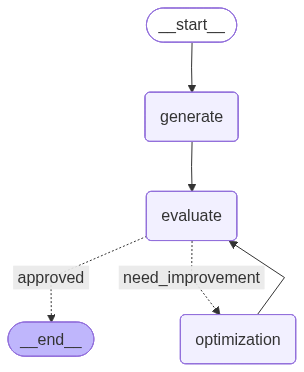

In [21]:
workflow = graph.compile()
workflow

In [25]:
initial_state = {
    "topic": "egdhkf",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)
result

{'topic': 'egdhkf',
 'tweet': '"Realized today \'egdhkf\' is just the sound my keyboard makes when I argue with my ISP. Plot twist: it’s actually a secret FBI code for ‘we’re out of donuts’. 🎯 #MysterySolved"',
 'evaluation': 'approved',
 'feedback': 'This tweet excels in originality with its absurd twist on a mundane scenario, blending relatable frustration (ISP arguments) with a surreal FBI punchline. The humor is sharp and unexpected, leveraging the contrast between mundane and conspiratorial. Its punchy structure—combining a keyboard smash, twist, and hashtag—is scroll-stopping and concise. The joke avoids traditional setups, staying under 280 characters while maximizing virality through shareable absurdity.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Realized today \'egdhkf\' is just the sound my keyboard makes when I argue with my ISP. Plot twist: it’s actually a secret FBI code for ‘we’re out of donuts’. 🎯 #MysterySolved"'],
 'feedback_history': ['This tweet exc